<a href="https://colab.research.google.com/github/Vrushabhadandin18/python/blob/main/Titanicpassenger.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. **Problem Statement**
 During the Titanic disaster, passenger survival was influenced by factors such as age, gender, and passenger class. The objective of this project is to build a binary classification machine learning model to predict whether a passenger survived (Yes/No) using historical passenger data and to identify the most important factors affecting survival.

**2. Objectives of the Project**

*  Understand passenger survival patterns
*  Perform basic data preprocessing
*  Conduct minimal but meaningful EDA
*  Build binary classification models
*  Evaluate model performance
*  Evaluate model performance







In [3]:
from google.colab import files
upload=files.upload()

Saving train.csv to train.csv


In [4]:
import pandas as pd
df=pd.read_csv("train.csv")
print(df)

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

In [5]:
print("dataset shape:",df.shape)

dataset shape: (891, 12)


In [6]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
886,False
887,False
888,False
889,False


In [7]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [8]:
num_cols=["Age"]
for col in num_cols:
  df[col]=df[col].fillna(df[col].median())
num_cols1=["Embarked"]
for c in num_cols1:
  df[c]=df[c].fillna(df[c].mode())
print(df)
if 'Cabin' in df.columns:
  df.drop(columns=['Cabin'],inplace=True)

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import r2_score
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

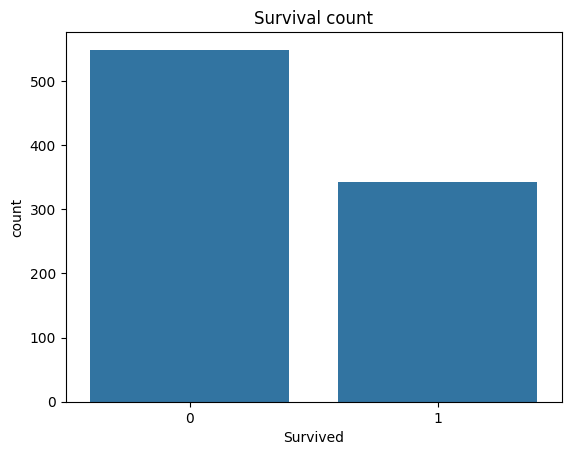

In [10]:
#graph survival count
sns.countplot(x='Survived',data=df)
plt.title("Survival count")
plt.show()

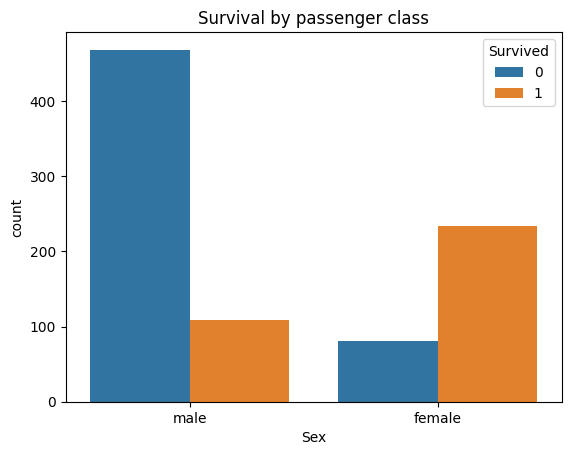

In [11]:
sns.countplot(x='Sex',hue='Survived',data=df)
plt.title("Survival by passenger class")
plt.show()

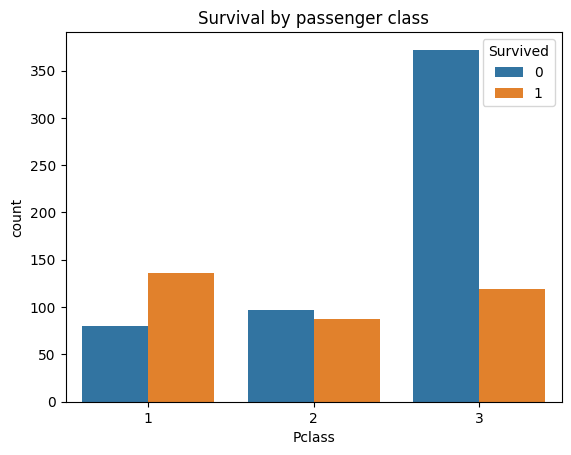

In [12]:
sns.countplot(x='Pclass',hue='Survived',data=df)
plt.title("Survival by passenger class")
plt.show()

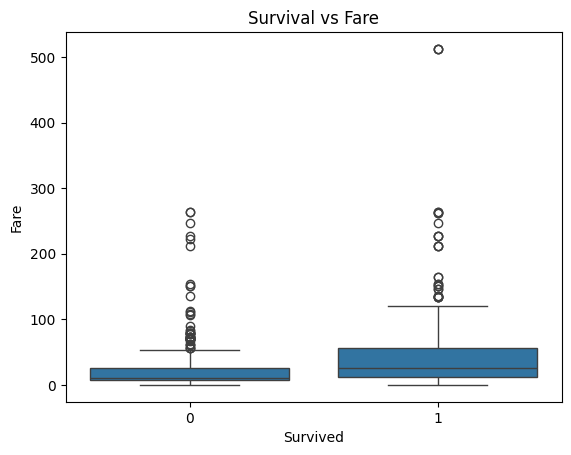

In [13]:
sns.boxplot(x='Survived',y='Fare',data=df)
plt.title('Survival vs Fare')
plt.show()

In [14]:
le=LabelEncoder()
df["Sex"]=le.fit_transform(df["Sex"])
df['Embarked']=le.fit_transform(df['Embarked'])
print(df)

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name  Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    1  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...    0  38.0      1   
2                               Heikkinen, Miss. Laina    0  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)    0  35.0      1   
4                             Allen, Mr. William Henry    1  35.0      0   
..                                                 ...  ...   ...    ...   
886        

In [15]:
X=df[["Pclass","Sex","Age","Parch","Fare","Embarked"]]
y=df[["Survived"]]

In [16]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
X,y,test_size=0.2,random_state=42
)

In [17]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [18]:
print("Survived(1) or not (0):,Predicated[0]")
#decision tree
from sklearn.tree import DecisionTreeClassifier


Survived(1) or not (0):,Predicated[0]


In [19]:
X=df[["Pclass","Sex","Age","Parch","Fare","Embarked"]]
y=df[["Survived"]]

In [20]:
X_train,X_test,y_train,y_test=train_test_split(
X,y,test_size=0.2,random_state=42
)

In [21]:
model=DecisionTreeClassifier(criterion="gini",max_depth=3)
model.fit(X_train,y_train)


DecisionTreeClassifier(max_depth=3)

In [22]:
y_pred=model.predict(X_test)
print("Predicated:",y_pred)


Predicated: [0 0 0 1 1 1 1 0 1 1 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0 1 0 0 0
 1 1 0 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 1 0 1 1 1 0 1 1 0 0 1 0 0 0 1 1 1 0 1
 0 0 1 1 1 1 0 1 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1
 0 1 0 0 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 1 0 0 1 0 1 1 0 0 1 0 1 0 0 0 1 0 0
 1 0 0 0 0 0 0 0 0 1 1 1 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 1 1]


In [23]:
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

Accuracy: 0.7988826815642458


In [26]:
from typing_extensions import evaluate_forward_ref
def evalute_model(y_test,y_pred):
  print("Accuracy:",accuracy_score(y_test,y_pred))
  print("precision:",precision_score(y_test,y_pred))
  print("recall:",recall_score(y_test,y_pred))
  print("F1_score:",f1_score(y_test,y_pred))
  evaluate_model(y_test,y_pred)

In [32]:
from sklearn.metrics import confusion_matrix,classification_report
import matplotlib.pyplot as plt
import seaborn as sns
cm=confusion_matrix(y_test,y_pred)

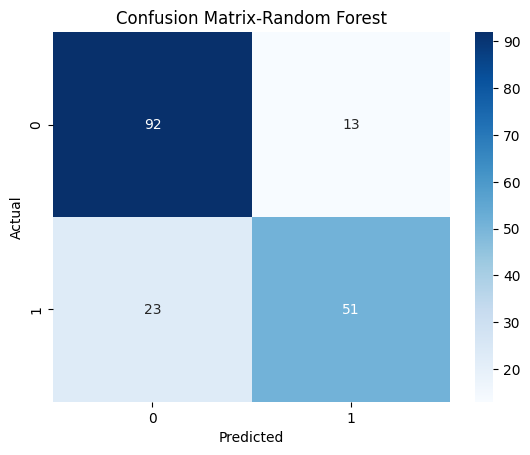

In [34]:
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix-Random Forest')
plt.show()

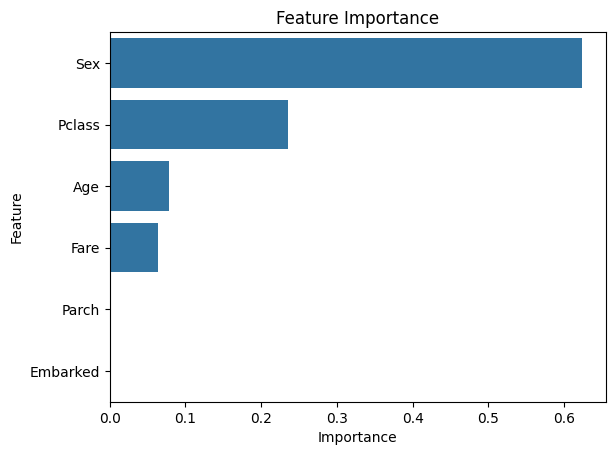

In [35]:
importances=model.feature_importances_
feature_names=X_train.columns
feat_df=pd.DataFrame({
    'Feature':feature_names,
    'Importance':importances,
}).sort_values(by='Importance',ascending=False)

sns.barplot(x='Importance',y='Feature',data=feat_df)
plt.title('Feature Importance')
plt.show()